# 2D CT Simulation Pipeline: Theory & Equations

This notebook explains the mathematical and physical foundations of our CT Simulation pipeline, strictly following the equations from **Medical Imaging Signals and Systems (Prince & Links)**.

## 1. Forward Projection (Data Acquisition)

The physical process of X-rays passing through a patient is governed by the **Beer-Lambert Law**:

$$ I = I_0 e^{-\int \mu(x,y) dl} $$

Where:
* $I_0$ is the incident X-ray intensity (number of photons).
* $I$ is the detected intensity.
* $\mu(x,y)$ is the linear attenuation coefficient of the tissue at location $(x,y)$.

By taking the negative natural logarithm, we isolate the line integral, which is our projection data $p$:

$$ p = -\ln\left(\frac{I}{I_0}\right) = \int \mu(x,y) dl $$

### The Radon Transform
In our code (`src/forward_projection.py`), we simulate parallel-beam geometry. This means $p$ is the **Radon Transform** of the object, defined by the line $s = x\cos\theta + y\sin\theta$:

$$ p(s, \theta) = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} \mu(x,y) \delta(x\cos\theta + y\sin\theta - s) dx dy $$

To compute this discretely, we trace parallel rays across the image grid. The parametric equations for a ray at offset $s$ and angle $\theta$ are:

$$ x(t) = s\cos\theta - t\sin\theta $$
$$ y(t) = s\sin\theta + t\cos\theta $$

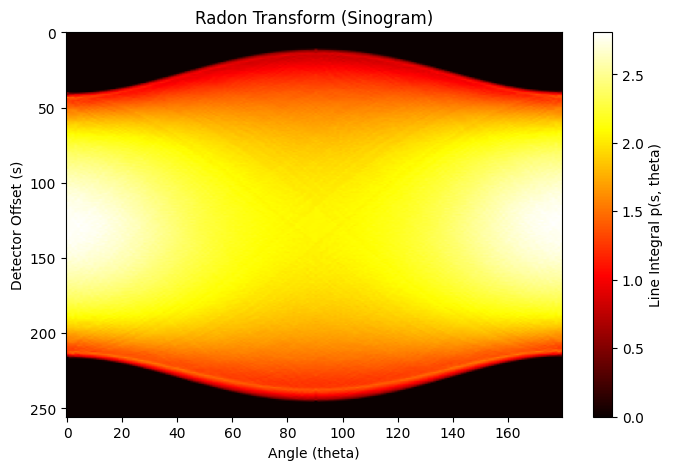

In [1]:
# Example: Generating the clean Sinogram p(s, theta)
import os, sys
sys.path.append(os.path.abspath("../src"))
from phantom import generate_shepp_logan
from forward_projection import generate_sinogram
import matplotlib.pyplot as plt

phantom = generate_shepp_logan(256)
clean_sino, angles = generate_sinogram(phantom, 180)

plt.figure(figsize=(8,5))
plt.imshow(clean_sino, cmap="hot", aspect="auto")
plt.title("Radon Transform (Sinogram)")
plt.xlabel("Angle (theta)")
plt.ylabel("Detector Offset (s)")
plt.colorbar(label="Line Integral p(s, theta)")
plt.show()

## 2. Noise Modeling (Poisson Statistics)

X-ray photon detection is a **Poisson process**. Noise does *not* exist directly in the Radon transform domain; it exists in the raw photon counts. Therefore, our code (`src/noise_model.py`) converts the clean sinogram back to photon intensity before adding noise.

$$ I_{expected} = I_0 e^{-p(s, \theta)} $$
$$ I_{measured} \sim \text{Poisson}(I_{expected}) $$

For a Poisson distribution, the variance equals the mean:
$$ \text{Var}(I) = E[I] = I $$

This creates the fundamental dose-noise tradeoff. The relative noise (Standard Deviation / Mean) is:
$$ \frac{\sigma}{\mu} = \frac{\sqrt{I}}{I} = \frac{1}{\sqrt{I}} $$

If we reduce the dose $I_0$ by a factor of 4, the noise doubles! After generating $I_{measured}$, we log-transform it back into a noisy sinogram:
$$ p_{noisy} = -\ln\left(\frac{I_{measured}}{I_0}\right) $$

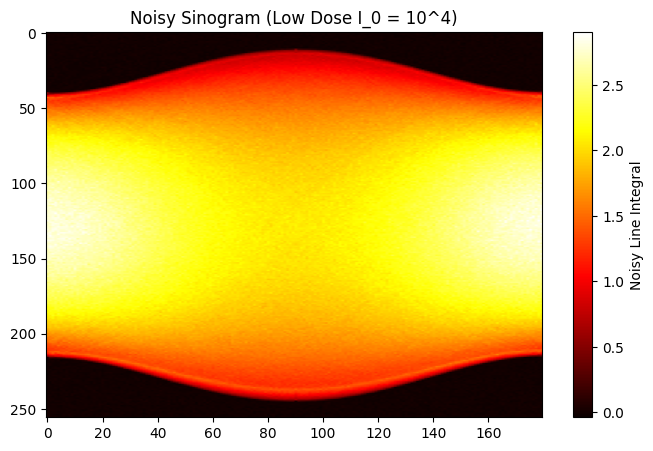

In [2]:
# Example: Adding Poisson Noise
from noise_model import add_poisson_noise

noisy_sino, noisy_intensity = add_poisson_noise(clean_sino, I0=1e4)

plt.figure(figsize=(8,5))
plt.imshow(noisy_sino, cmap="hot", aspect="auto")
plt.title("Noisy Sinogram (Low Dose I_0 = 10^4)")
plt.colorbar(label="Noisy Line Integral")
plt.show()

## 3. Filtered Back-Projection (Reconstruction)

FBP is based on the **Fourier Slice Theorem**, which states that the 1D Fourier Transform of a projection at angle $\theta$ is a slice of the 2D Fourier Transform of the original object at angle $\theta$.

In our code (`src/fbp.py`), reconstruction is a two-step process:

### Step 3a: Filtering
To correct for the non-uniform sampling density in polar coordinates, we must multiply the frequency domain by a ramp filter $|\omega|$. To control noise, we multiply by an apodization window $H(\omega)$ (e.g., Hamming, Cosine).

$$ p_{filtered}(\theta, s) = \mathcal{F}^{-1} \{ |\omega| \cdot H(\omega) \cdot \mathcal{F}\{ p(\theta, s) \} \} $$

### Step 3b: Back-Projection
We smear the filtered projections back across the image grid. For each pixel $(x,y)$, we find the corresponding detector offset $s$ and sum over all angles:

$$ \mu(x,y) = \int_0^\pi p_{filtered}(\theta, x\cos\theta + y\sin\theta) d\theta $$

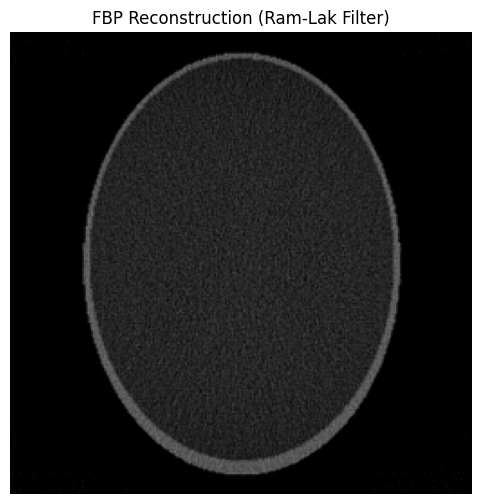

In [3]:
# Example: Reconstructing the Noisy Sinogram using FBP
from fbp import reconstruct_fbp

reconstruction = reconstruct_fbp(noisy_sino, angles, filter_name="ram-lak")

plt.figure(figsize=(6,6))
plt.imshow(reconstruction, cmap="gray", vmin=0, vmax=0.05)
plt.title("FBP Reconstruction (Ram-Lak Filter)")
plt.axis("off")
plt.show()

## 4. System Performance Evaluation

Our system characterizes the scanner using three clinical metrics.

### 4a. Spatial Resolution (MTF)
The Modulation Transfer Function (MTF) measures how well the system preserves spatial frequencies. We extract the Edge Spread Function (ESF), take the derivative to get the Line Spread Function (LSF), and take the Fourier transform:

$$ \text{LSF}(x) = \frac{d}{dx} \text{ESF}(x) $$
$$ \text{MTF}(f) = |\mathcal{F}\{\text{LSF}(x)\}| $$

### 4b. Noise Texture (NPS)
The Noise Power Spectrum (NPS) tells us *where* the noise energy sits in the frequency domain. It is heavily influenced by the reconstruction filter.

$$ \text{NPS}(u,v) = \frac{\Delta x \Delta y}{N_x N_y} \langle |\mathcal{F}\{\text{ROI}_{noise}\}|^2 \rangle $$

### 4c. Object Detectability (CNR)
The Contrast-to-Noise Ratio (CNR) uses the **Rose Criterion** ($CNR \geq 3$) to determine if a human observer can detect a tumor.

$$ \text{CNR} = \frac{|\mu_{insert} - \mu_{background}|}{\sigma_{background}} $$